In [ ]:
# Import necessary libraries for data processing, visualization, and machine learning
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Set random seed for reproducibility and define class names for CIFAR-10 dataset
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [ ]:
# Load CIFAR-10 dataset, preprocess labels and normalize images
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Flatten labels from shape (n, 1) to (n,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Train full: (50000, 32, 32, 3) (50000,)
Test: (10000, 32, 32, 3) (10000,)


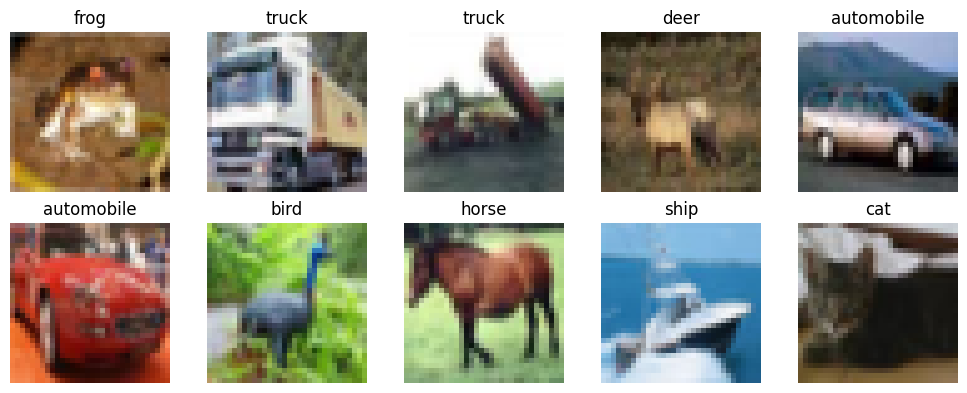

In [ ]:
# Display sample images from the CIFAR-10 training set
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Split training data into labeled and unlabeled sets for semi-supervised learning
labeled_ratio = 0.15

x_labeled, x_unlabeled, y_labeled, _ = train_test_split(
    x_train_full,
    y_train_full,
    test_size=(1 - labeled_ratio),
    stratify=y_train_full,
    random_state=SEED
)

print("Labeled set:", x_labeled.shape, y_labeled.shape)
print("Unlabeled set:", x_unlabeled.shape)

Labeled set: (7500, 32, 32, 3) (7500,)
Unlabeled set: (42500, 32, 32, 3)
Test set: (10000, 32, 32, 3) (10000,)


In [ ]:
# Define data augmentation layers for image preprocessing
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
])

In [ ]:
# Define a convolutional neural network model for image classification
def create_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Return the compiled model
return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Set up early stopping callback and train the baseline supervised model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_supervised = baseline_model.fit(
    x_labeled,
    y_labeled,
    validation_split=0.2,
    epochs=12,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2753 - loss: 2.0954 - val_accuracy: 0.1420 - val_loss: 3.9932
Epoch 2/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3598 - loss: 1.7851 - val_accuracy: 0.1787 - val_loss: 4.5606
Epoch 3/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4018 - loss: 1.6443 - val_accuracy: 0.2327 - val_loss: 3.7747
Epoch 4/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4265 - loss: 1.5747 - val_accuracy: 0.2620 - val_loss: 3.2796
Epoch 5/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4650 - loss: 1.4931 - val_accuracy: 0.3273 - val_loss: 2.2683
Epoch 6/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.4675 - loss: 1.4539 - val_accuracy: 0.3293 - val_loss: 2.6081
Epoch 7/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4923 - loss: 1.4064 - val_accuracy: 0.5073 - val_loss: 1.4146
Epoch 8/12
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5093 - loss: 1.3378 - val_accuracy: 0.5013 - v

In [ ]:
# Generate predictions on test set using the baseline model
baseline_probs = baseline_model.predict(x_test, verbose=0)

Baseline Test Accuracy: 0.5131


In [ ]:
# Convert baseline probabilities to predictions and calculate accuracy
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)
print("Baseline Test Accuracy:", round(baseline_acc, 4))

In [ ]:
# Print the classification report for the baseline model predictions
print(classification_report(y_test, baseline_preds, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.69      0.46      0.55      1000
  automobile       0.66      0.54      0.60      1000
        bird       0.43      0.14      0.21      1000
         cat       0.46      0.17      0.25      1000
        deer       0.42      0.52      0.47      1000
         dog       0.45      0.46      0.46      1000
        frog       0.60      0.72      0.65      1000
       horse       0.44      0.81      0.57      1000
        ship       0.78      0.49      0.61      1000
       truck       0.43      0.81      0.56      1000

    accuracy                           0.51     10000
   macro avg       0.54      0.51      0.49     10000
weighted avg       0.54      0.51      0.49     10000



In [ ]:
# Generate pseudo-labels from unlabeled data using the baseline model with confidence thresholding
unlabeled_probs = baseline_model.predict(x_unlabeled, verbose=0)
pseudo_labels = np.argmax(unlabeled_probs, axis=1)
confidence_scores = np.max(unlabeled_probs, axis=1)

threshold = 0.95
mask = confidence_scores >= threshold

x_pseudo = x_unlabeled[mask]
y_pseudo = pseudo_labels[mask]

print("Threshold:", threshold)
print("Pseudo-labeled samples kept:", len(x_pseudo))
print("Rejected samples:", len(x_unlabeled) - len(x_pseudo))

Threshold: 0.95
Pseudo-labeled samples kept: 3536
Rejected samples: 38964


In [ ]:
# Combine labeled and pseudo-labeled data for semi-supervised training
x_combined = np.concatenate([x_labeled, x_pseudo], axis=0)
y_combined = np.concatenate([y_labeled, y_pseudo], axis=0)

print("Combined training set:", x_combined.shape, y_combined.shape)

Combined training set: (11036, 32, 32, 3) (11036,)


In [ ]:
# Create and train the semi-supervised model using combined labeled and pseudo-labeled data
ssl_model = create_model()

history_ssl = ssl_model.fit(
    x_combined,
    y_combined,
    validation_split=0.2,
    epochs=12,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3725 - loss: 1.8552 - val_accuracy: 0.1223 - val_loss: 4.7179
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4599 - loss: 1.5383 - val_accuracy: 0.1984 - val_loss: 3.3626
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5145 - loss: 1.3996 - val_accuracy: 0.7726 - val_loss: 0.6324
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5404 - loss: 1.3138 - val_accuracy: 0.9438 - val_loss: 0.2741
Epoch 5/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5546 - loss: 1.2624 - val_accuracy: 0.9402 - val_loss: 0.2108
Epoch 6/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5718 - loss: 1.2044 - val_accuracy: 0.9601 - val_loss: 0.1698
Epoch 7/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.5916 - loss: 1.1634 - val_accuracy: 0.9697 - val_loss: 0.0981
Epoch 8/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6012 - loss: 1.1187 - val_accu

In [ ]:
# Evaluate the semi-supervised model on the test set
ssl_probs = ssl_model.predict(x_test, verbose=0)
ssl_preds = np.argmax(ssl_probs, axis=1)

ssl_acc = accuracy_score(y_test, ssl_preds)
print("Semi-Supervised Test Accuracy:", round(ssl_acc, 4))

Semi-Supervised Test Accuracy: 0.5853


In [ ]:
# Print the classification report for the semi-supervised model predictions
print(classification_report(y_test, ssl_preds, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.75      0.50      0.60      1000
  automobile       0.65      0.70      0.68      1000
        bird       0.48      0.51      0.49      1000
         cat       0.43      0.33      0.37      1000
        deer       0.73      0.36      0.48      1000
         dog       0.54      0.49      0.51      1000
        frog       0.53      0.83      0.65      1000
       horse       0.65      0.70      0.67      1000
        ship       0.74      0.68      0.71      1000
       truck       0.52      0.76      0.62      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.58     10000
weighted avg       0.60      0.59      0.58     10000



In [ ]:
# Compare the accuracies of baseline and semi-supervised models
print(f"Baseline Accuracy:        {baseline_acc:.4f}")
print(f"Semi-Supervised Accuracy: {ssl_acc:.4f}")
print(f"Improvement:              {ssl_acc - baseline_acc:.4f}")

Baseline Accuracy:        0.5131
Semi-Supervised Accuracy: 0.5853
Improvement:              0.0722


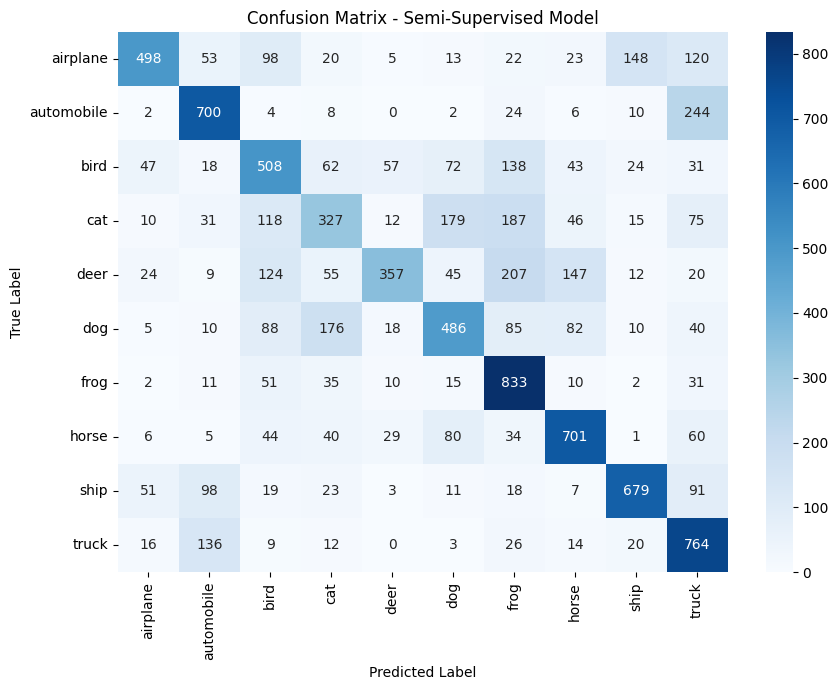

In [ ]:
# Plot the confusion matrix for the semi-supervised model predictions
cm = confusion_matrix(y_test, ssl_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Semi-Supervised Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# Define a function to plot training history (accuracy and loss curves)
def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

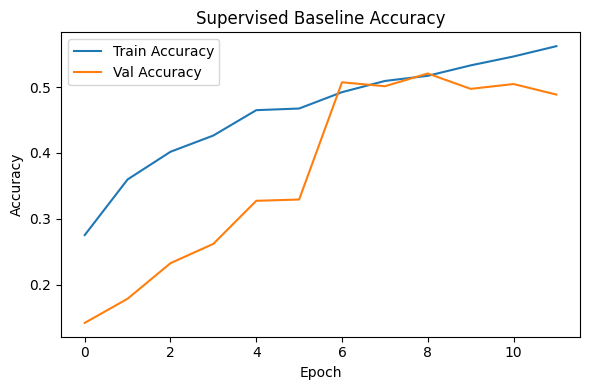

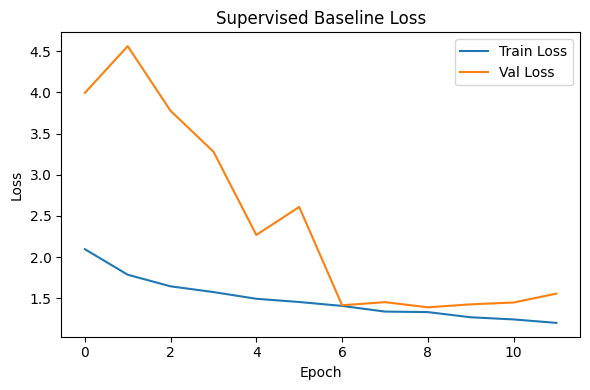

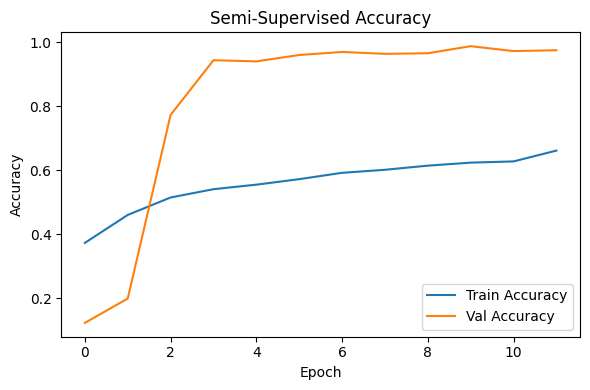

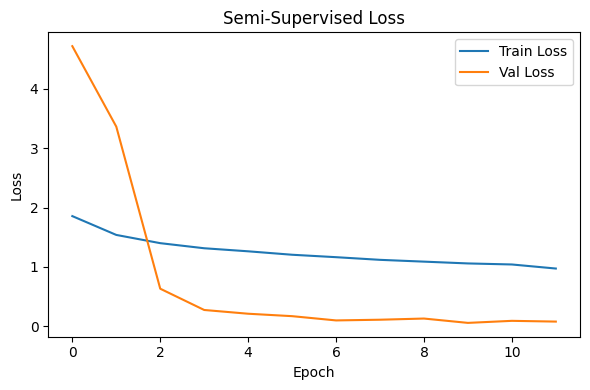

In [ ]:
# Plot training histories for both supervised baseline and semi-supervised models
plot_history(history_supervised, "Supervised Baseline")
plot_history(history_ssl, "Semi-Supervised")

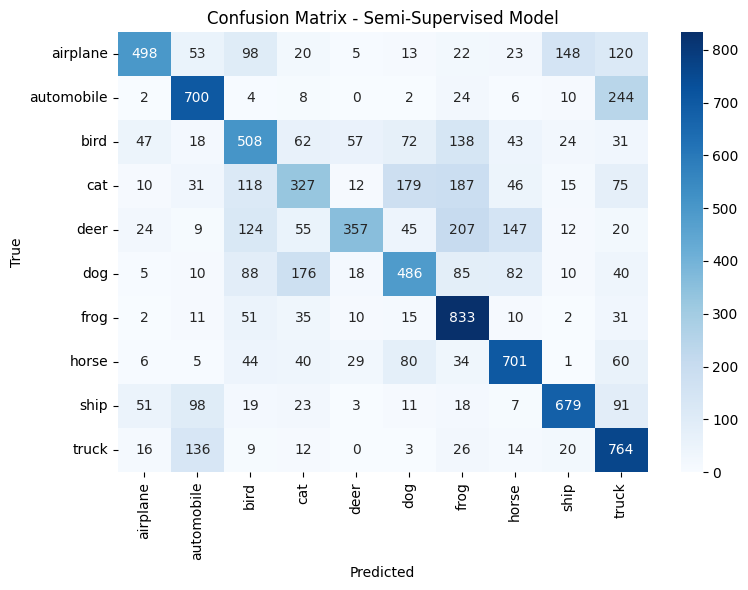

In [ ]:
# Save the confusion matrix plot to a file
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Semi-Supervised Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix_ssl.png", dpi=200, bbox_inches="tight")
plt.show()

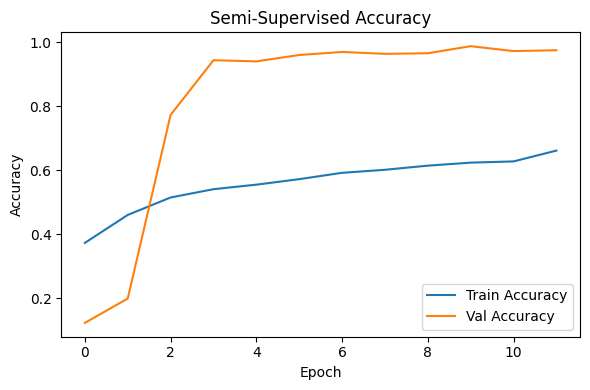

In [ ]:
# Save the accuracy curve plot for the semi-supervised model
plt.figure(figsize=(6, 4))
plt.plot(history_ssl.history["accuracy"], label="Train Accuracy")
plt.plot(history_ssl.history["val_accuracy"], label="Val Accuracy")
plt.title("Semi-Supervised Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("ssl_accuracy_curve.png", dpi=200, bbox_inches="tight")
plt.show()

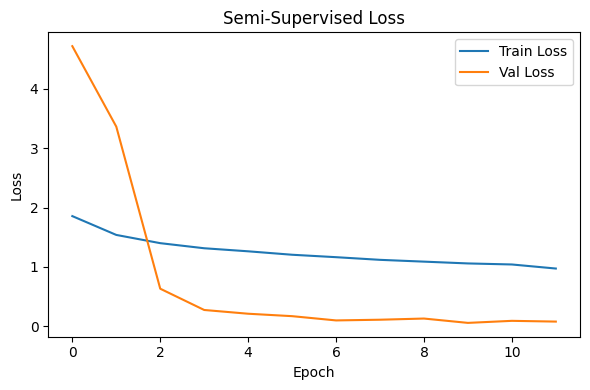

In [ ]:
# Save the loss curve plot for the semi-supervised model
plt.figure(figsize=(6, 4))
plt.plot(history_ssl.history["loss"], label="Train Loss")
plt.plot(history_ssl.history["val_loss"], label="Val Loss")
plt.title("Semi-Supervised Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("ssl_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Print key observations and summary of the semi-supervised learning experiment
print(f"""
Observations:
- The baseline supervised model was trained on only {int(labeled_ratio * 100)}% of the CIFAR-10 training data.
- Pseudo-labeling increased the effective training set size by adding {len(x_pseudo)} high-confidence unlabeled samples.
- The semi-supervised model achieved a test accuracy of {ssl_acc:.4f}, compared to {baseline_acc:.4f} for the supervised baseline.
- Classes with visually similar features, such as cat and dog, remained more difficult to classify.
- Confidence thresholding helped reduce noisy pseudo-labels and improved the reliability of the semi-supervised stage.
""")


Observations:
- The baseline supervised model was trained on only 15% of the CIFAR-10 training data.
- Pseudo-labeling increased the effective training set size by adding 3536 high-confidence unlabeled samples.
- The semi-supervised model achieved a test accuracy of 0.5853, compared to 0.5131 for the supervised baseline.
- Classes with visually similar features, such as cat and dog, remained more difficult to classify.
- Confidence thresholding helped reduce noisy pseudo-labels and improved the reliability of the semi-supervised stage.

